<div align="center">

# Pricing a Floating-Strike Asian Call Option on Apple Inc.

### A Binomial Tree and Normal Approximation Approach

---

**6,252: Stochastic Methods in Finance**
University of St. Gallen
Instructor: Dr. Enrico Giorgi

**Alexandru Puspurica** · **Clement Durix**

May 18, 2026

</div>


## Table of Contents

0. [Introduction](#intro)
1. [Data and Parameter Estimation](#data)
2. [The Binomial Tree Model](#binomial)
3. [Robustness Check](#robustness)
4. [Sanity Check via Monte Carlo](#mc)
5. [Normal Approximation](#normal)
6. [Conclusion](#conclusion)
A. [Appendix: Derivations](#appendix)

---

<a id="intro"></a>
## 0. Introduction

We consider a six-month floating-strike Asian call on Apple Inc. (AAPL) common stock. Writing $S_t$ for the AAPL price at monitoring date $t = 0, 1, \dots, n$ and

$$
\bar{S}_n \;=\; \frac{1}{n+1}\sum_{t=0}^{n} S_t
$$

for the mean over the $n+1$ monitoring dates (with $t = 0$ counted, so $n = 25$ transitions yield $26$ observations), the contract pays at maturity

$$
A_n \;=\; \max\bigl(S_n - \bar{S}_n,\, 0\bigr) \qquad\qquad (1)
$$

The instrument is monitored weekly over a maturity of $T = 0.5$ years, the risk-free rate is fixed at $r = 1\%$ per annum, and the volatility $\sigma$ is calibrated from AAPL historical daily log-returns spanning 2020–2026.

Because the payoff in (1) depends not only on the terminal price $S_n$ but also on the mean $\bar{S}_n$ — which is itself determined by the specific path leading to $S_n$ — two paths reaching the same node with the same number of up and down moves can carry different averages and therefore different payoffs. The valuation is, in this sense, *path-dependent*.

We obtain the arbitrage-free price of (1) by two independent routes. First, we construct a Cox–Ross–Rubinstein (CRR) binomial tree, and to accommodate path-dependence we augment the state space so that each path carries its running cumulative sum

$$
C_t \;=\; \sum_{j=0}^{t} S_j,
$$

from which the running average is recoverable at every node. Under the risk-neutral probability measure $Q$, the value at each node is the expectation of its two successor values weighted by the risk-neutral probability $q$, multiplied by the one-step discount factor $e^{-r\Delta t}$ where $\Delta t = T/n$. Iterating this recursion back to $t = 0$ compounds the per-step discount into the full discount factor $e^{-rT}$, yielding the arbitrage-free price

$$
C_0 \;=\; e^{-rT}\,\mathbb{E}^{Q}\!\left[A_n\right].
$$

Second, *[PLACEHOLDER — normal-approximation method, to be written by [group member's name]: brief description of approximating $D_n = S_n - \bar{S}_n$ as Gaussian under $Q$, deriving its first two moments, and applying the closed-form expectation of a censored normal random variable to obtain a price in closed form.]*

As an independent check on the binomial price, a Monte Carlo simulation of risk-neutral paths is also performed.

In [ ]:
# Import all the packages we need
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns
import math
import time



<a id="data"></a>
## 1. Data and Parameter Estimation

The first step is to use historical Apple stock prices from 2020 to 2026 to estimate $\sigma$; to do this we use an API. The Yahoo Finance API specified in the project is no longer free, so instead we use a free alternative named Stooq. No sign-up was required; however, an API key had to be obtained from the CSV-download page of the Stooq website.

To pull the data, a function is defined that reads the CSV directly from the AAPL URL; the resulting series is then sorted by date and the date is set as the index for easy access. We subsequently call this function to retain only the dates relevant to the project.

To verify completeness, we check the number of observations against the project’s assumption of approximately 250 trading days per year, and the count obtained from the pulled data is consistent with this benchmark.

In [3]:

APIKEY = "COa2gJQuK0X1c4DihNGzTxIFH8pf3Md7"

def get_aapl_prices():
    url = f"https://stooq.com/q/d/l/?s=aapl.us&i=d&apikey={APIKEY}"
    data = pd.read_csv(url)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values("Date")
    return data.set_index("Date")["Close"]

#set the stock prices we got equal to a variable
all_prices = get_aapl_prices()

#select only the prices for the timeframe which was asked for the project
prices = all_prices.loc["2020-01-01":"2026-04-30"]

#lets see the amount of loaded prices from the start date to the end date
print("Loaded", len(prices), "daily prices from", prices.index[0].date(), "to", prices.index[-1].date())
print("Exexpected data points around: ", 250*(2026-2020))


Loaded 1590 daily prices from 2020-01-02 to 2026-04-30
Exexpected data points around:  1500


Now that we have our data lets graph the retuns and log returns to ensure our data looks clean before estimating sigma.


Log returns are commonly used in finance because for small movements they are approximately equal to the simple return,

$$
r_t \;=\; \log(1 + R_t) \;\approx\; R_t \qquad \text{for small } R_t,
$$

and they are additive over time which greatly reduces computational needs when running financial calculations.

$$
\log\!\left(\frac{S_n}{S_0}\right) \;=\; \sum_{t=1}^{n} r_t.
$$

From Chapter 1 (lecture slide 58, *Stochastic Methods in Finance*) the log-return is defined as

$$
r_t \;:=\; \log\!\left(\frac{S_t}{S_{t-1}}\right) \;=\; \log S_t - \log S_{t-1}, \qquad\qquad (2)
$$

Also log returns are what is used in both the binomial tree and the geometric Brownian motion models which we have to use later on, where the variance condition takes the form

$$
\operatorname{Var}\!\left[\log\!\left(\frac{S_n}{S_0}\right)\right] \;=\; \sigma^2 T.
$$


Missing prices: 0
Missing log returns: 0


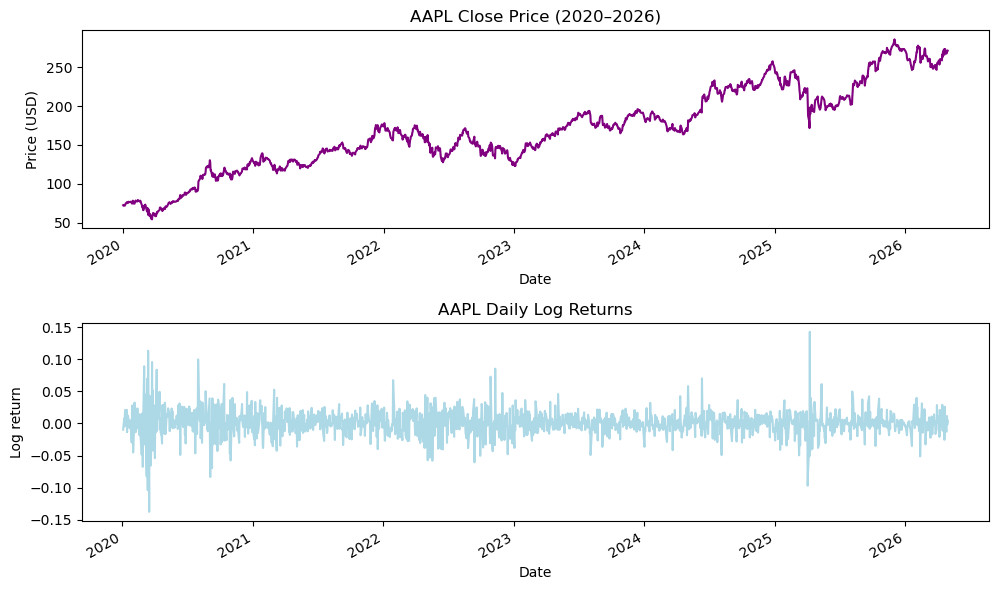

In [4]:
log_returns = np.log(prices / prices.shift(1)).dropna() # The first row is NA becuse there is no S0_t-1 so we have a dropna() to remove this one problematic row

# Even before printing i want to make sure that there are no missing values because I've had difficulty in the past with this
print("Missing prices:", prices.isna().sum())
print("Missing log returns:", log_returns.isna().sum())

#Lets make a plot for apple stock closing prices and the log returns
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020–2026)", color="purple")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="lightblue")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()


Now that we have pulled the data and computed the log-returns we need to create the parameters, most of which were given in the assignment, that are used by the floating-strike Asian price model. For the initial price $S_0$ we use the last day of trading we have from our data.

Sigma is the only parameter which we are estimating, which is done under the assumption that AAPL follows a geometric Brownian motion, $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$. Applying Itô's lemma gives us the constant variance log price process $d(\log S_t) = (\mu - \tfrac{1}{2}\sigma^2)\,dt + \sigma\,dW_t$, so the variance of one daily log-return (Equation 2) equals $\sigma_{\text{daily}}^2$. Sigma is then estimated as $\sigma_{\text{daily}}$, which is the sample standard deviation of the log-return series, its then turned into an annual value under the 250 trading day convention which was given in the assignment.

$$
\sigma \;=\; \sigma_{\text{daily}} \cdot \sqrt{250},  \qquad\qquad (3)
$$

this formula is justified by the linear scaling of variance with time under the i.i.d. assumption.

The up and down factors of the binomial tree are then chosen so that one tree step matches the variance of one $\Delta t$-step of the underlying geometric Brownian motion (Cox, Ross, & Rubinstein, 1979; Chapter 2). The standard CRR choice is

$$
u \;=\; e^{\sigma\sqrt{\Delta t}}, \qquad d \;=\; e^{-\sigma\sqrt{\Delta t}} \;=\; \frac{1}{u}, \quad (\text{see Appendix A.1}) \qquad\qquad (4)
$$

with the physical up-probability set to $p = \tfrac{1}{2}$ as stated in the project instructions.


In [5]:
# Parameters given by the assignment

# Maturity
T  = 0.5
# Number of binomial periods
n  = 25
#change in time for each period
dt = T / n
# Risk-free rate per annum
r  = 0.01
# the probability of an up move
p = 0.5
# Initial stock price (last day of trading)
S0 = all_prices.loc["2026-04-28"]


# Now we have to find sigma

#we compute the daily volitility 
sigma_daily = log_returns.std()

#rescale to a yearly value (convention of CRR)
sigma = sigma_daily * np.sqrt(250) 


# use simga to compute u and d as given by our derived formulas

# e ^ sigma * sqrt(dt)
u = np.exp(sigma * np.sqrt(dt))
# e ^ -sigma * sqrt(dt) or 1/u
d = np.exp(-sigma * np.sqrt(dt))


# Before we move on lets so a sanity check to make sure all the variables look like something we would expect

print(f"T            = {T}")
print(f"n            = {n}")
print(f"r            = {r}")
print(f"S_0          = {S0:.2f} USD")
print(f"sigma_daily  = {sigma_daily:.6f}")
print(f"sigma_annual = {sigma:.6f}")
print(f"u            = {u:.6f}")
print(f"d            = {d:.6f}")
print(f"p            = {p}")


T            = 0.5
n            = 25
r            = 0.01
S_0          = 270.71 USD
sigma_daily  = 0.019784
sigma_annual = 0.312816
u            = 1.045232
d            = 0.956725
p            = 0.5


<a id="binomial"></a>
## 2. The Binomial Tree Model

The physical up-probability $p = \tfrac{1}{2}$ is the probability of the number of up moves and down moves in nature but p can not be used to price the option directly because its an unobservable value which is based on your beleive about the stock; two participants disagreeing on $p$ would still have to agree on the price for the derivative otherwise one could arbitrage the other. The arbitrage-free price must therefore depend only on observable quantities — $S_0$, $u$, $d$ and $r$ and not subjective belief. Sigma is included through the derivations of u and d which were done above

For this reason we caculutate the **risk-neutral probability** $q$, which is the synthetic up probability where the discounted stock price is martingale meaning its  expected future value given everything known today equals its current value. Solving $S_t = e^{-r\Delta t}\,\mathbb{E}^Q[S_{t+\Delta t}\mid\mathcal{F}_t]$ for $q$ gives

$$
q \;=\; \frac{e^{r\Delta t} - d}{u - d}, \quad (\text{see Appendix A.2}) \qquad\qquad (5)
$$

which has the domain $(0,1)$ only if the no-arbitrage condition $d < e^{r\Delta t} < u$ holds The Fundamental Theorem of Asset Pricing (Chapter 2) then guarantees that the arbitrage-free price of any derivative is its discounted expected payoff under $Q$, a principle we apply by backward induction in the cells that follow.



In [6]:
q = (np.exp(r * dt) - d) / (u - d)

# if q is outside (0,1) the model would admit to arbitrage and an assumption of modern markets is no arbitrage so lets make a sanity check on q to make sure everything is fine. If something is wrong the program will crash. 
assert 0 < q < 1, f"q = {q:.4f} outside (0,1) — model admits arbitrage!"

print(f"q = {q:.6f}")


q = 0.491202


Because the payoff from equation (1) depends on the entire path through the average $\bar{S}_n$, the option value at an interior node cannot be expressed as a function of the up-count $j$ alone. This is because two paths reaching the same $(t, j)$ probably have different running averages because the up and down moves scale by a percentage of the price and the base price being different depening on the previous moves. Therefore they have different future payoffs. We resolve this by augmenting the states with the running cumulative sum $C_t = \sum_{k=0}^{t} S_k$, where the running average $\bar{S}_t = C_t/(t+1)$ is accessable at every node (Chapter 2, *Stochastic Methods in Finance* lecture notes).

Keeping all of this in mind, we need to structure the tree as `list[dict[set]]`: `states[t]` 

Where the stucture look something like this:

$$\texttt{states[0]} = \bigl\{\, 0 : \{S_0\} \,\bigr\}$$

$$\texttt{states[1]} = \bigl\{\, 0 : \{S_0 + S_0 d\},\;\; 1 : \{S_0 + S_0 u\} \,\bigr\}$$

$$\texttt{states[2]} = \bigl\{\, 0 : \{S_0 + S_0 d + S_0 d^{2}\},\;\; 1 : \{\underbrace{S_0 + S_0 u + S_0 ud}_{\text{path UD}},\; \underbrace{S_0 + S_0 d + S_0 du}_{\text{path DU}}\},\;\; 2 : \{S_0 + S_0 u + S_0 u^{2}\} \,\bigr\}$$

The middle node at $(t=2,\, j=1)$, is reached by **two distinct paths** both ending at the same stock price $S_2 = S_0\,ud$. However, their cumulative sums differ because the intermediate price was $S_0 u$ on one path and $S_0 d$ on the other. The set $\texttt{states[2][1]}$ therefore has two elements, one for each path history, and each one will be assigned its own payoff at maturity and its own value during the backward pass. This is a small exmple of path dependency


Once the parameters $T$, $n$, $\sigma$, $r$ and $S_0$ are fixed, the function computes the per-step constants

$$
\Delta t \;=\; \tfrac{T}{n}, \qquad u \;=\; e^{\sigma\sqrt{\Delta t}}, \qquad d \;=\; e^{-\sigma\sqrt{\Delta t}}, \qquad q \;=\; \tfrac{e^{r\Delta t} - d}{u - d}, \qquad \mathrm{disc} \;=\; e^{-r\Delta t},
$$

u, d, q being defined in equations (4) and (5). The tree is then initialised at $t = 0$ by placing the single triple $(0,\, 0,\, C_0)$ with $C_0 = S_0$ 

The **forward iteration** iterates over the $n$ transitions $t = 0, 1, \ldots, n-1$. At each existing triple $(t, j, C)$ the path-independent node price

$$
S_{t,j} \;=\; S_0\,u^{\,j}\,d^{\,t-j}
$$

once its computed this triple generates two childer (i) one with up-count $j+1$ and cumulative sum $C + S_{t,j}\,u$ and (ii) one with up-count $j$ (unchanged) and cumulative sum $C + S_{t,j}\,d$:

$$
(t, j, C) \;\longrightarrow\; \begin{cases} (t+1,\, j+1,\, C + S_{t,j}\,u) & \text{(up)}, \\[2pt] (t+1,\, j,\;\;\, C + S_{t,j}\,d) & \text{(down)}. \end{cases} \quad (\text{see Appendix A.3}) \qquad\qquad (6)
$$

Also in the foward iteration a new set is created in `states[t+1]` only when the child up-count does not yet have one, so reads come only from level $t$ and writes only to level $t+1$ so we dont mess up any past nodes

At maturity ($t = n$), each terminal triple $(n, j, C)$ produces the floating-strike Asian call payoff

$$
A_n(j, C) \;=\; \max\!\bigl(S_{n,j} - C/(n+1),\, 0\bigr),
$$

which is a modification of equation (1) with $\bar{S}_n$ rewritten as $C/(n+1)$. We set the minimun value to zero because if we lose money for the option we simply dont redeem it

The **backward iteration** then runs from $t = n-1$ down to $t = 0$, applying the risk-neutral pricing relation at every node:

$$
V_t(j, C) \;=\; \mathrm{disc}\,\bigl[\,q\,V_{t+1}\!\bigl(j+1,\, C + S_{t,j}\,u\bigr) \;+\; (1-q)\,V_{t+1}\!\bigl(j,\, C + S_{t,j}\,d\bigr)\,\bigr]. \quad (\text{see Appendix A.4}) \qquad\qquad (7)
$$

Each parent value is the discounted risk-neutral expectation of its two children which are looked up via the same $C$-update rule as in the forward iteration. Iterating (7) collapses the entire tree onto the unique root $(t=0,\,j=0,\,C=S_0)$, and the function returns $V_0(0, S_0)$ which is the arbitrage-free price of the option today.

In [7]:

def floating_asian_option_pricer(S0, sigma, r, T, n):
    # The first step is to define our varibales from the value of the given parameters
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = np.exp(-sigma * np.sqrt(dt))
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # The next step is to create the structure of our tree and every possible outcome which is done using states where each possible outcome gives birth to two child outcomes which are a summing cumulative product of S0 and u and d which we will then map values to in a later function
    # The tree need the shape list[dict[set]] as descibed above where:
        #state[t] is the dictionary at each time point
        #states[t][j] is the set of all reachable cumulative sums C at not (t,j)
    # We need to make a nested path because the option is path dependent and we need to keep them seperate without having the number of of dictionaries explode which would grossly affect the computing efficiency
    states = []
    
    # The tree has n transitions but n+1 time points: t = 0, dt, 2dt, ..., n·dt = T and we need a dict at every time point, so range is n+1,  don't forget t=0!
    for t in range(n + 1): 
        # For each of the steps we create a dictionary which is keyed by the number of up moves so far and where values get filled by foward pass
        states.append({})
    # We also need to set the initial cumulative sum to S0 since only one price is recorded at t=0; this is our starting point
    states[0][0] = {S0}

    # Now we need to define what happens at each time step above; we made the time points but now we need to define what happens in the transitions
    # For every time t we need to spawn two children one with up move values and one with down move values

    # Things to consider
        # We have to make sure to only read from t and only write into t+1 so we dont mess up any past nodes while making the transitions
        # Use range(n) because here we are doing the transitions not the time points 
    for t in range(n):
        #now we have to loop over every up move so we iterate through every key strored in states[t]
        for j in list(states[t].keys()):
            #now on each iteration we set one specific up count value 0, then 1, then 2, ect. through states[t][j] which is a set containing every distinct cumulative sum through all paths that point to this state node
            c_set = states[t][j] #specified as value to avoid repeated hashing and for readability

            # we now have to compute the current stock price at each j in each t to do that we just nultiply S0 by the number of up moves and the up move value and the number of down moves and the down move value this value is path independent
            S_now = S0 * (u ** j) * (d ** (t - j))

            #we are now inside the t and j loop so now we are at a specific node where c_set is the set of all cummulative sums recorded at that node
            # in c_set are elements containing the path history that arrived at (t,j) on each pass c must be calculated as one specific float 
            for C in c_set:
                # now we need if j+1 (childs up count) is not already a key in states[t+1] (the dict for the next time level) then we need to cteate a new empty set at that key to store the C values 
                if (j + 1) not in states[t + 1]:
                    states[t + 1][j + 1] = set()
                #then we add the value of the the up move to the C value for the next time frame
                states[t + 1][j + 1].add(C + S_now * u)
                # We do the same thing for the down count but we have to remember not to change the up count so NO j+1 on the index and to use d instead of u
                if j not in states[t + 1]:
                    states[t + 1][j] = set()
                states[t + 1][j].add(C + S_now * d)

    # Now that we calulcuated the states we need to calculate the values
    values = []

    # We again make a dictionary at each time point +1
    for t in range(n + 1):
        values.append({})

    # Now we acess each last time level n which have key values of j which includes all j values of (0->n) (all up moves, all down moves, and everything inbetweem).
    for j in states[n]:
        # Then we compute the terminal value at the right most part of the tree from top to botoom and fill values for all S terminal values at that time step n this is not S-now but S_t becuase is the terminal price at maturity.
        S_T = S0 * (u ** j) * (d ** (n - j))
        # Next we make an empty dictionary at this slot in values to map the cummulative sums to option values where each c is a key and each payofff will be the value
        values[n][j] = {}

        # Now we loop over every cumulative sum C which is one path history that reached (n,j)
        for C in states[n][j]:
            # At each C we calculate the maturity at payooff for each node using the floating-strike asian call payoff formula
            payoff = S_T - C / (n + 1) # (see Appendix A.4)

            # Make sure negative payoffs are zero because call options can never have a negative payoff; you simply would not exercise an option if you lose money.
            payoff = max(payoff,0.0)
            # For each time frame and each up move count set the value of the cumulative sum
            values[n][j][C] = payoff

# So far we've built the full grid of reachable augmented states (t, j, C) in the forward pass and pinned down the option's payoff at every terminal node (t=n).
# All that's left is backward induction where we have to take the terminal payoffs and roll them back through the tree and at each node compute the discounted risk neutral expected value of its two children
# until we collapse everything down to a single number at (t=0, j=0, C=S0) giving us the arbitrage-free option price today.

    # We start at n-1 for backword induction because n was already filled bye the termila payoffs and go all the way to 0, you must include -1 as the stop value because python does not include the stop value in the formula, the step must be -1 because we are counting backwards
    for t in range(n - 1, -1, -1):
        # For every up count j at this time level we process every node 
        for j in states[t]:
            # We compute the current stock price at node which is path independnet so its lives outside the C loop
            S_now = S0 * (u ** j) * (d ** (t - j))
            # We now make an empty dictionary at this node to holde the C->V mappings
            values[t][j] = {}
            # Next we loop through each c which is one sepciifc path history to get the value of the up child and the down child because to compute the option value we need to know these two values which are filled in from the pervious loop
            for C in states[t][j]:
                # We need to get the values by accessing the dict at the next time level up, get the childs up count which is one more than the parents and inside that dict look up the entry for the childs cumulative sum
                # The childs cumulative sum is the cumalitive sum of the parent plus the price now times u or d respectivally
                V_up = values[t + 1][j + 1][C + S_now * u] 
                V_dn = values[t + 1][j    ][C + S_now * d]
                # Now we have to use the formula that actually computes the option value at this node which is the discounted risk-neutral expectation of the two children
                # V_t = disc * (q * V_up + (1-q) * V_dn) — derived from the replication argument
                # (see Appendix A.4, Equation 7)
                # We then use the value the formula gave out and index it to the current time frame at the correct j count  in the slot for the cummulative sum
                values[t][j][C] = disc * (q * V_up + (1 - q) * V_dn)

    # We return the abritrage free price of the option today which is just the first node of the backward inductuon and then we access the key for the first original parent value S0
    return values[0][0][S0] 

In [8]:
%%time
# Now that we defined the function lets actually run it and also see how long it takes.

price_binomial = floating_asian_option_pricer(S0, sigma, r, T, n)

print(f"Binomial price at t=0 : {price_binomial:.4f} USD")


Binomial price at t=0 : 14.0418 USD
CPU times: user 2.04 s, sys: 92.8 ms, total: 2.14 s
Wall time: 2.15 s


<a id="robustness"></a>
## 3. Robustness Check

From the 5 inputs which are used in the modal, $T$, $n$ and $r$ are given by the assignment instructions and $S_0$ is observed directly, meaning the only parameter which has real uncertainty is $\sigma$. Although $r$ was given in the assignment in the real worlds it's set externally by central bank policy and could change over the six month life of our contract meaning we need to treat both $r$ and $\sigma$ as parameters worth stress testing to get a more holistic view of what could possibly happen with our option valuation

To do this stress test we conduct a two way scenario based robustness check by varying $r$ and $\sigma$ jointly over a discrete $5 \times 5$ grid around their baseline values rather than one at a time, since the price is nonlinear in $\sigma$ and a joint sweep also captures interaction effects between the two parameters.

The grid is centred on the baseline $(\hat{\sigma},\, r = 1\%)$ so that the central cell reproduces the price from §2, with

$$
r \in \{0\%,\, 0.5\%,\, 1\%,\, 1.5\%,\, 2\%\}
$$

which is a resonable range to assume based in historical central bank rate decisions. For $\sigma$ we instead scale our baseline estimate $\hat{\sigma}$ multiplicatively over

$$
\{0.8,\, 0.9,\, 1.0,\, 1.1,\, 1.2\}\,\hat{\sigma}
$$

to span a $\pm 20\%$ band around the historical estimate. The price is recomputed at every $(\sigma, r)$ pair using using our price function; the resulting price surface is reported in the table below, and in the heatmap that follows it which shows the profit-and-loss (P&L) for the option holder relative to the baseline price.

Elapsed time: 59.38 s


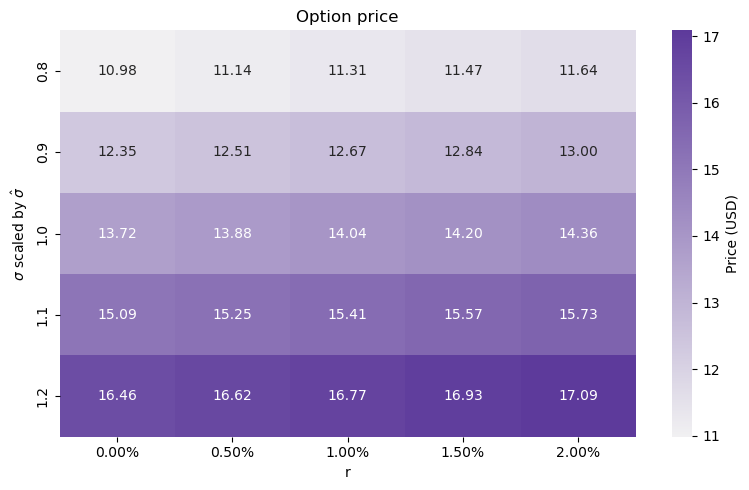

In [9]:
# First we define our grids
r_grid     = [0.0, 0.005, 0.01, 0.015, 0.02]
sigma_grid = [sigma * 0.8, sigma * 0.9, sigma, sigma * 1.1, sigma * 1.2]

#we have to constuct a dataframe in which sigma is the index and the interest rate is the features 
results = pd.DataFrame(
    index=[f"{s:.4f}" for s in sigma_grid],
    columns=[f"{rr:.2%}" for rr in r_grid],
    dtype=float,
)

#Label the index and the columns to help us visualize our data
results.index.name   = "sigma"
results.columns.name = "r"

#Now we have to loop our option pricing formula over each interest rate at each sigma and we can use a nested for loop for that
start_time = time.time()
for s_val in sigma_grid:
    for r_val in r_grid:
        price = floating_asian_option_pricer(S0, s_val, r_val, T, n)
        results.loc[f"{s_val:.4f}", f"{r_val:.2%}"] = price
print(f"Elapsed time: {time.time() - start_time:.2f} s")

# Now lets print our results in a nice graph

# whitish (low prices) -> medium-dark purple (high prices) sequential colormap
purple_cmap = sns.light_palette("#5d3a9b", as_cmap=True)

# relabel sigma index with just the multiplier of the baseline sigma_hat so the y-axis matches the {0.8, 0.9, 1.0, 1.1, 1.2} sigma_hat grid we defined above
multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]
results_labeled = results.copy()
results_labeled.index = [f"{m:.1f}" for m in multipliers]

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)  # turn off the global rcParams grid so it doesnt draw lines through the heatmap cells
sns.heatmap(results_labeled, annot=True, fmt=".2f", cmap=purple_cmap,
            cbar_kws={"label": "Price (USD)"}, ax=ax)
ax.set_title("Option price")
ax.set_xlabel("r")
ax.set_ylabel(r"$\sigma$ scaled by $\hat{\sigma}$")
plt.tight_layout()
plt.show()

The table above shows the absolute arbitrage free price of the option at every $(\sigma, r)$ pair on the grid for the option holder, however, the quantity of practical interest is not the absolute price itself but how much each scenario diverges from the baseline $(\hat{\sigma},\, r = 1\%)$ specified in the assignment, since that is the price actually paid for the option under no-arbitrage conditions. We therefore re-express price minus the no arbitrage value, so that each cell quantifies the gain or loss relative to the calculated baseline price. Since the contract is a call option and we adopt the perspective of the option holder (i.e. the buyer), scenarios in which the recomputed fair price exceeds the baseline produce a profit while scenarios in which it falls short produce a loss. Again, in reality if we were to realise a loss we would simply not exercise our option.

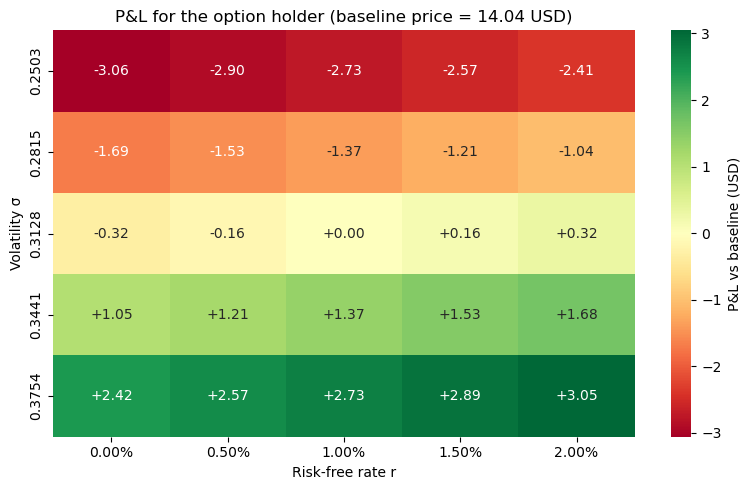

In [10]:

baseline = results.loc[f"{sigma:.4f}", f"{r:.2%}"]
# P&L from the buyer's perspective: realized fair price minus what we paid at baseline
pnl = results - baseline

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)  # turn off the global rcParams grid so it doesnt draw lines through the heatmap cells
# RdYlGn: red for negative (loss), yellow near zero, green for profit — like a stock-market P&L heatmap
sns.heatmap(pnl, annot=True, fmt="+.2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "P&L vs baseline (USD)"}, ax=ax)
ax.set_title(f"P&L for the option holder (baseline price = {baseline:.2f} USD)")
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Volatility σ")
plt.tight_layout()
plt.show()

<a id="mc"></a>
## 4. Sanity Check via Monte Carlo


A Monte Carlo simulation is when the computer rolls dice thousands of times to figure something out instead of calculating it directly. We have the simulation pretend Apple's stock is going on a random 6 month journey and run 200,000 different versions of that journey each with a different patterrn of ups and downs. For each journey we calculate out what our option would have paid out at the end then average all those payouts together to get a second estimate of the option's price.
This is a great way to double check our binomial tree because its a completely different mathemeatical foundation for calculating the price and if the two methods disagree then something must have gone wrong. 

In [11]:
# Not a required part of the assignment but as an extra sanity check for the model lets run a monte carlo simulation to see if our call option pricer actually worked

#We need a function that takes the same inputs as the option pricer and also a number of paths for random simulations and a seed for replicability
def monte_carlo_floating_asian_option_pricer(S0, sigma, r, T, n, n_sims=200_000, seed=42):
    
    # Set the random seed so we get the same result every run
    np.random.seed(seed)
    
    # Length of one time step
    dt = T / n
    
    # Pre-draw all the random numbers we need at once: one matrix of shape (n_sims, n)
    Z = np.random.standard_normal((n_sims, n))
    
    # Container for the payoff of each simulated path
    payoffs = np.zeros(n_sims)
    
    # Loop over each simulated path
    for i in range(n_sims):
        
        # Start the path at S0
        price_path = [S0]
        
        # Simulate n forward steps
        for t in range(n):
            # GBM log-return for this step (risk-neutral dynamics)
            log_return = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z[i, t]
            
            # New price = old price * exp(log_return)
            new_price = price_path[-1] * math.exp(log_return)
            price_path.append(new_price)
        
        # Average price along this path
        avg_price = sum(price_path) / len(price_path)
        
        # Terminal price is the last entry of the path
        terminal_price = price_path[-1]
        
        # Floating-strike Asian call payoff: max(S_n - average, 0)
        payoffs[i] = max(terminal_price - avg_price, 0)
    
    # Discounted expected payoff = Monte Carlo price estimate
    price = math.exp(-r * T) * payoffs.mean()
    
    # Standard error of the estimate
    se = math.exp(-r * T) * payoffs.std(ddof=1) / math.sqrt(n_sims)
    
    return price, se


# Run the Monte Carlo and compare with the binomial price 

mc_price, mc_se = monte_carlo_floating_asian_option_pricer(S0, sigma, r, T, n)

# 95% confidence interval
ci_lo = mc_price - 1.96 * mc_se
ci_hi = mc_price + 1.96 * mc_se

# Print results
print(f"Monte Carlo (200k paths) : {mc_price:.4f} USD")
print(f"  95% CI                 : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Binomial price           : {price_binomial:.4f} USD")
print(f"Absolute difference      : {abs(mc_price - price_binomial):.4f} USD")

Monte Carlo (200k paths) : 13.9071 USD
  95% CI                 : [13.8050, 14.0092]
Binomial price           : 14.0418 USD
Absolute difference      : 0.1346 USD


<a id="normal"></a>
## 5. Normal Approximation
The augmented-state binomial pricer of Section 2 delivers the arbitrage-free price exactly, but at a cost: the augmented tree no longer recombines, so the number of states grows as $2^n$. For $n = 25$ this is on the order of 33 million states, tractable but expensive, and entirely impractical at higher monitoring frequencies. We seek a closed-form alternative.

Following the assignment's task (vii), we approximate the distribution of

$$
D_n \;:=\; S_n - \bar{S}_n \;=\; S_n - \frac{1}{n+1}\sum_{t=0}^{n} S_t
$$

by a normal distribution. The contract's payoff $\max(D_n, 0)$ then admits a closed-form expectation under the normal approximation (the *Bachelier identity*), which combined with risk-neutral discounting yields a one-line pricer.

It is worth emphasising what the approximation *is* and *is not*. The first two moments $\mu_D := \mathbb{E}^{\mathbb{Q}}[D_n]$ and $\sigma_D^2 := \mathrm{Var}^{\mathbb{Q}}(D_n)$ are computed **exactly** under the discrete CRR model, with no approximation: they follow from elementary properties of expectation and from the i.i.d. structure of returns under $\mathbb{Q}$. The single approximation is in *replacing the unknown distribution of $D_n$ by a normal with these exact moments*. The justification is heuristic, drawing on the Central Limit Theorem (Chapter 1, slide 44) and the joint approximate lognormality of the path under $\mathbb{Q}$ (Chapter 1, slide 66): $D_n$ is a linear combination of $S_t$&apos;s (each itself a product of i.i.d. log-returns), and such linear combinations tend toward normality for moderate $n$. The pricing error this introduces is quantified empirically by comparison to the exact binomial price.

The pipeline is:

1. **Per-step return moments under $\mathbb{Q}$**: $m_1 = q u + (1-q) d$ and $m_2 = q u^2 + (1-q) d^2$. (Appendix A.5)
2. **Path mean vector**: $\mathbb{E}[S_t] = S_0 \cdot m_1^t$ for each $t$. (Appendix A.6)
3. **Path covariance matrix** $V$: from the master moment $\mathbb{E}[S_s S_t] = S_0^2 \cdot m_2^{\min(s,t)} \cdot m_1^{|t-s|}$. (Appendix A.7)
4. **Linear-combination form** $D_n = \sum_t a_t S_t$ with explicit coefficients $a_t$. (Appendix A.8)
5. **Mean and variance** of $D_n$: $\mu_D = a^\top \mathbb{E}[S]$ and $\sigma_D^2 = a^\top V a$. (Appendices A.9, A.10)
6. **Bachelier identity** for $\mathbb{E}[\max(X, 0)]$ when $X \sim \mathcal{N}(\mu, \sigma^2)$. (Appendix A.11)
7. **Discounted risk-neutral price** by the FTAP. (Appendix A.4)

In [12]:
# we compute expectations with the risk-neutral probability measure
# each one-step return (R_t := S_{t+1} / S_t) takes value u with the probabilities q and d = 1-q.
# There are two raw moments that appear constantly in everything below:

# m_1 = E^Q[R_t]   = q · u + (1 - q) · d
# m_2 = E^Q[R_t²]  = q · u² + (1 - q) · d²

# -------------------------------------------------------------------------------------------------------------------

m1 = q * u + (1 - q) * d                       # First raw moment of one step return
m2 = q * u**2 + (1 - q) * d**2                 # Second raw moment (E[R_t²])

# -------------------------------------------------------------------------------------------------------------------

# Under Q the returns per each step R_1, R_2, ..., R_t are i.i.d., so the expectation of the product factors is defined as:

#     E[S_t] = E[ S_0 · R_1 · R_2 · ... · R_t ]
#            = S_0 · E[R_1] · E[R_2] · ... · E[R_t]      (thanks to independence)
#            = S_0 · m_1^t                               (each R_i has mean m_1)

# -------------------------------------------------------------------------------------------------------------------
 
ES = np.zeros(n + 1)                           # we set vector ES = (E[S_0], E[S_1], ..., E[S_n])
for t in range(n + 1):                         # we loop over all n+1 steps t ∈ {0, 1, ..., n}
    ES[t] = S0 * m1**t                         # we apply E[S_t] = S_0 · m_1^t
 
# -------------------------------------------------------------------------------------------------------------------

# we will later compute Var(D_n) with Var(D_n) = a^T V a. (D_n = S_n − S̄_n) So we need to fill in every entry V[s, t] = Cov(S_s, S_t) for s, where t ∈ {0, ..., n}.
# We already know that Cov(X, Y) = E[XY] - E[X] E[Y], and since the means E[S_t] are already in hand from step B, the ingredient we still need is the cross-moment  E[S_s · S_t]  for every pair (s, t).
# If we try to do the direct computation of all pairs E[S_s · S_t] it would be a nighmare (summing over all 2^n paths).
# But there is a way to rewrite S_t in a way that exposes independent factors.  if we take two time-steps (s is one time step and t is another) and that we set s ≤ t , we can write:
# S_t = S_s · (S_t / S_s) 

# Why this rewriting?  Because the factor S_s only depends on returns within the window [0, s] while the factor S_t/S_s only depends on returns in the window [s, t].  
# Those two windows are DISJOINT, and returns in disjoint windows are independent under Q. 
# This independence lets us then factor the expectation:

#     E[S_s · S_t] = E[S_s · S_s · (S_t/S_s)]
#                  = E[S_s²] · E[S_t/S_s]                 (independence mentionned above)
#                  = (S_0² · m_2^s) · (m_1^(t-s))         (Each piece takes the same i.i.d.-product argument we used in the last step. In more details, firstly, E[S_s²] = S_0² · m_2^s —> we write S_s² = S_0² · R_1² · R_2² · ... · R_s²; in here, the R_i²'s are mutually independent (as R_i's are), so the expectation factors into s copies of E[R_i²] = m_2. ||| secondly, E[S_t / S_s] = m_1^(t−s) —> we write S_t/S_s = R_{s+1} · ... · R_t, a product of t−s independent returns each with mean m_1.)
#                  = S_0² · m_2^s · m_1^(t-s)


# So if we have arbitrary s, t (without setting s ≤ t) the symmetric shape is:

# E[S_s · S_t] = S_0² · m_2^min(s,t) · m_1^|t-s|       (★)


# From (★) we get the covariance:

#     Cov(S_s, S_t) = E[S_s S_t] - E[S_s] E[S_t]
#                   = S_0² · ( m_2^min(s,t) · m_1^|t-s|  -  m_1^(s+t) ).

# -------------------------------------------------------------------------------------------------------------------
 
V = np.zeros((n + 1, n + 1))                              # Create (n+1)×(n+1) covariance matrix
for s in range(n + 1):                                    # Outer loop: row index s ∈ {0, ..., n}
    for t in range(n + 1):                                # Inner loop: column index t ∈ {0, ..., n}
        E_SsSt  = S0**2 * m2**min(s, t) * m1**abs(s - t)  # (★) at indices (s, t)
        V[s, t] = E_SsSt - ES[s] * ES[t]                  # Cov(S_s, S_t) = E[S_s S_t] - E[S_s] E[S_t]

# -------------------------------------------------------------------------------------------------------------------

# In the last step we will compute Var(D_n) by using what we learnt in the lecture with the portfolio-variance formula:

#     Var(R_x) = x^T V x

# which applies to any linear combination of random variables ("x" is the vector of weights and "V" the covariance matrix of the underlying variables).
# So before we can use the formula we need to express D_n in exactly that shape: Σ (some weight) · (some S_t), with the weights gathered in a vector that we can then plug into the formula.

# but how we get it? The definition for D_n (which i remind you is the term we use for S_n − S̄_n) is:
# D_n = S_n - (1/(n+1)) · Σ_{t=0}^n S_t

# as you can see, the second term is already a linear combination of the S_t's. But the first term is outside the sum.  
# So we just distribute the 1/(n+1) across all the terms of the sum and then group by which S_t each piece multiplies:

#     D_n  =  S_n  -  S_0/(n+1)  -  S_1/(n+1)  -  …  -  S_n/(n+1)


# So:

#     coefficient on S_n   =   1 - 1/(n+1)     Notice on the formula sitting right above that one how S_n appears twice: once with coefficient +1 (the first term) and once with coefficient -1/(n+1). That's how we get the coefficient S_n.
#     coefficient on S_t   =   -1/(n+1)        this is for every t < n (see formula of D_n right above)

# Now if we call these coefficients a_t we get the form we need:

# D_n  =  Σ_{t=0}^n  a_t · S_t

# with

# a_n  =  1 - 1/(n+1)             <- terminal-price weight (large, positive)
# a_t  =  -1/(n+1)    for t < n   <- every earlier-price weight (small, negative)

# -------------------------------------------------------------------------------------------------------------------

a = np.full(n + 1, -1 / (n + 1))           # Initialize all coefficients to -1/(n+1)
a[n] = 1 - 1 / (n + 1)                     # Override the terminal coefficient to 1 - 1/(n+1)

# -------------------------------------------------------------------------------------------------------------------

# The base plan is to approximate D_n by a normal  N(μ_D, σ_D²) and then apply the Bachelier identity at the end to compute E[max(D_n, 0)].  
# But the Bachelier formula takes two inputs: the mean μ_D and the std σ_D of the normal.  
# Here, we now compute in this step the mean μ_D.

# We know from the lecture that:
#     μ_D = E[D_n] = Σ_t  a_t · E[S_t] = a^T · ES

# -------------------------------------------------------------------------------------------------------------------

mu_D = a @ ES     # μ_D = Σ_t a_t · E[S_t]   ("@" is the dot product in numpy)

# -------------------------------------------------------------------------------------------------------------------

# Now we compute the the standard deviation σ_D
# We learnt in the lectures the formula for the variance of a linear combination of correlated random variables, for weight vector x and covariance matrix V:

# Var(R_x) = x^T V x

# We apply it with x = a (from 2 steps above) and V = the full covariance matrix (we built in the 3rd step):

# σ_D²  :=  Var(D_n)  =  a^T V a

# this is one matrix-vector product which is followed by one dot product

# -------------------------------------------------------------------------------------------------------------------
 
var_D    = a @ V @ a                           # σ_D² = a^T V a (Chapter 5 formula applied to D_n)
sigma_D  = np.sqrt(var_D)                      # σ_D, the standard deviation of D_n

# -------------------------------------------------------------------------------------------------------------------

# we now must compute E[max(D_n, 0)]

# Everything until now was "exact" algebra.
# However, what we don't have is the full distribution of D_n. If we want to Compute it exactly, we would need to sum over all 2^n = 33 million paths, which we won't attempt.
# so we replace D_n's true (unknown, awkward) distribution with a normal that has the same first two moments. The mean and variance are exact. It's only the *shape* of the distribution is the approximation.

# D_n  ≈  N(μ_D, σ_D²)

# Now that we set up the approximation, we now need a closed form expression for E[max(X, 0)] when X ~ N(μ, σ²). 
# We use a piece of integral calculus that has been known since Bachelier's 1900 thesis on option pricing:

# E[max(X, 0)]  =  μ · Φ(μ/σ)  +  σ · φ(μ/σ)

# where Φ is the standard normal CDF and φ is its PDF.

# it's made of two terms:
#    -  μ · Φ(μ/σ)  is the "drift" contribution: the mean of D_n times the probability that D_n ends up positive.
#    -  σ · φ(μ/σ)  is the "diffusion" contribution: optionality value coming from the spread around the mean. The φ evaluated at μ/σ peaks when μ/σ is small.

# ------------------------------------------------------------------------------------------------------------------- 

z = mu_D / sigma_D                               # it's the standardized "moneyness" of the contract
expected_payoff  = mu_D * norm.cdf(z) + sigma_D * norm.pdf(z)
 
# ------------------------------------------------------------------------------------------------------------------- 

# Finally, the Fundamental Theorem of Asset Pricing states that the arbitrage free price today is the discounted expected payoff. Therefore:
# V_0  =  e^(-rT) · E^Q[ max(D_n, 0) ]

# We can plug that in the Bachelier approximation from previous step and it'll give us the closed-form normal-approximation price.

# ------------------------------------------------------------------------------------------------------------------- 
 
price_normal = np.exp(-r * T) * expected_payoff        # we discount the expected payoff back to t=0

# -------------------------------------------------------------------------------------------------------------------

print("=" * 64)
print("  NORMAL-APPROXIMATION PRICING — INTERMEDIATE QUANTITIES")
print("=" * 64)
print(f"  m_1                       = {m1:.6f}    (= e^(r·dt) = {np.exp(r*dt):.6f})")
print(f"  m_2                       = {m2:.6f}")
print(f"  E[S_n]                    = {ES[n]:.4f}  USD")
print(f"  μ_D  := E[D_n]            = {mu_D:.4f}  USD")
print(f"  σ_D  := √Var[D_n]         = {sigma_D:.4f}  USD")
print(f"  z    = μ_D / σ_D          = {z:.4f}")
print("-" * 64)
print(f"  Normal-approx. price      = {price_normal:.4f}  USD")
print(f"  Binomial price (Section 2)= {price_binomial:.4f}  USD")
print(f"  Absolute difference       = {price_normal - price_binomial:+.4f}  USD")
print(f"  Relative difference       = {(price_normal - price_binomial)/price_binomial:+.2%}")
print("=" * 64)

  NORMAL-APPROXIMATION PRICING — INTERMEDIATE QUANTITIES
  m_1                       = 1.000200    (= e^(r·dt) = 1.000200)
  m_2                       = 1.002358
  E[S_n]                    = 272.0669  USD
  μ_D  := E[D_n]            = 0.6790  USD
  σ_D  := √Var[D_n]         = 35.0456  USD
  z    = μ_D / σ_D          = 0.0194
----------------------------------------------------------------
  Normal-approx. price      = 14.2519  USD
  Binomial price (Section 2)= 14.0418  USD
  Absolute difference       = +0.2101  USD
  Relative difference       = +1.50%


### Visual sanity check: the exact distribution of $D_n$ vs. the normal fit

We can verify the quality of the normal approximation directly by computing the *exact* $\mathbb{Q}$-distribution of $D_n$ from the augmented tree and overlaying the fitted normal density. The cell below propagates probability mass forward through the $(j, C)$ state space, visiting all $2^n$ paths but storing them compactly as nested dictionaries, and at $t = n$ reads off pairs $(D_n,\, \mathrm{prob})$ that fully characterise the distribution under $\mathbb{Q}$.

The histogram below is the *true* distribution; the red curve is the normal approximation we just used to price the option. Any misalignment between the two is exactly what produces the pricing gap reported above. In particular, watch for **asymmetry**: the histogram is right-skewed (heavier upper tail), which the symmetric normal cannot capture. This is the visual content of the skewness argument formalised in the discussion below.

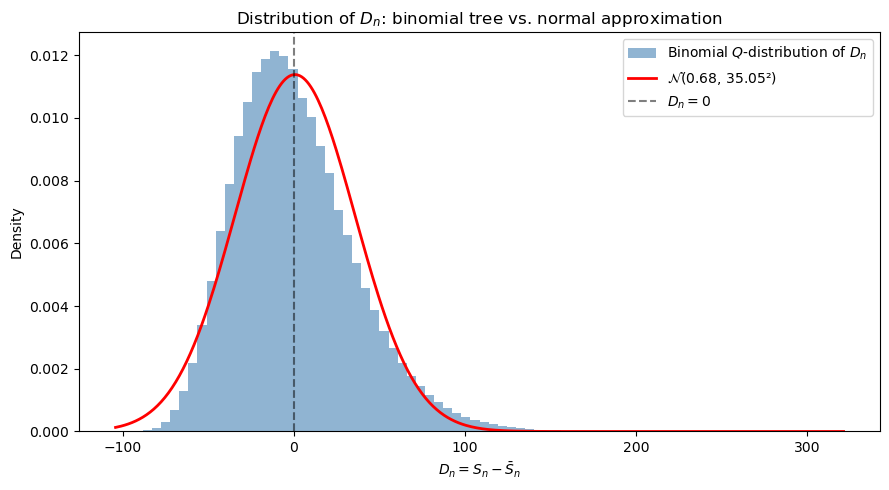

In [13]:
# Here starts the normal Approximation

prob_states = []
for t in range(n + 1):
    prob_states.append({})
prob_states[0][0] = {S0: 1.0}

for t in range(n):
    for j in list(prob_states[t].keys()):
        c_dict = prob_states[t][j]
        S_now  = S0 * (u**j) * (d**(t - j))
        for C in c_dict:
            prob = c_dict[C]
            if (j + 1) not in prob_states[t + 1]:
                prob_states[t + 1][j + 1] = {}
            new_C_up = C + S_now * u
            if new_C_up in prob_states[t + 1][j + 1]:
                prob_states[t + 1][j + 1][new_C_up] += prob * q
            else:
                prob_states[t + 1][j + 1][new_C_up] = prob * q
            if j not in prob_states[t + 1]:
                prob_states[t + 1][j] = {}
            new_C_dn = C + S_now * d
            if new_C_dn in prob_states[t + 1][j]:
                prob_states[t + 1][j][new_C_dn] += prob * (1 - q)
            else:
                prob_states[t + 1][j][new_C_dn] = prob * (1 - q)

Dn_values = []
Dn_probs  = []
for j in prob_states[n]:
    S_T = S0 * (u**j) * (d**(n - j))
    for C in prob_states[n][j]:
        Dn_values.append(S_T - C / (n + 1))
        Dn_probs.append(prob_states[n][j][C])
Dn_values = np.array(Dn_values)
Dn_probs  = np.array(Dn_probs)

assert abs(Dn_probs.sum() - 1.0) < 1e-9, "Q-probabilities must sum to 1"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(Dn_values, bins=80, weights=Dn_probs, density=True,
        alpha=0.6, color="steelblue", label=r"Binomial $Q$-distribution of $D_n$")
xx = np.linspace(Dn_values.min(), Dn_values.max(), 400)
ax.plot(xx, norm.pdf(xx, loc=mu_D, scale=sigma_D), "r-", lw=2,
        label=r"$\mathcal{N}$" + f"({mu_D:.2f}, {sigma_D:.2f}²)")
ax.axvline(0, color="k", linestyle="--", alpha=0.5, label=r"$D_n = 0$")
ax.set_xlabel(r"$D_n = S_n - \bar{S}_n$")
ax.set_ylabel("Density")
ax.set_title(r"Distribution of $D_n$: binomial tree vs. normal approximation")
ax.legend()
plt.tight_layout()
plt.show()

### Reading the output

The closed-form pricer yields

$$
V_0^{\text{normal}} \;=\; e^{-rT}\bigl[\,\mu_D \,\Phi(\mu_D/\sigma_D) \;+\; \sigma_D \,\varphi(\mu_D/\sigma_D)\bigr]
$$

with $\mu_D \approx 0.68$ USD and $\sigma_D \approx 35.05$ USD. Numerically the normal-approximation price comes in at approximately **14.25 USD**, against the exact binomial price of approximately **14.04 USD**, a relative gap of roughly **+1.50 %**.

The sign of the gap is informative. As the plot above makes visible, the true distribution of $D_n$ is *right-skewed*: $S_n$ is bounded below by zero but unbounded above (it is approximately lognormal under $\mathbb{Q}$), so $D_n$ inherits asymmetric tails. The normal approximation, symmetric by construction, cannot represent this skew. For a call payoff, which truncates the lower tail entirely and amplifies the upper tail, the normal misallocates a small amount of probability mass relative to the truth. In our parameter regime ($\sigma \approx 0.31$, $T = 0.5$, $n = 25$) the misallocation results in a slight *over-pricing* of the option by the normal approximation. This is consistent with the Monte Carlo cross-check of Section 4, whose 95 % confidence interval contains the binomial price but not the normal-approximation price.

A first-order check on the size of the gap: skewness of a sum of i.i.d. variables decays as $1/\sqrt{n}$ (a standard CLT-rate result, Chapter 1). Doubling $n$ should therefore shrink the gap by roughly a factor of $\sqrt{2}$, while doubling $\sigma$ should widen it (the underlying lognormal becomes more skewed). Both predictions can be verified by varying $n$ and $\sigma$ in the cell above.

<a id="conclusion"></a>
## 6. Conclusion

This report priced a European floating strike Asian call on Apple Inc. with a maturity of six months using an augmented state Cox Ross Rubinstein binomial tree under the assignment's parameters ($T = 0.5$, $n = 25$, $r = 1\%$, $\sigma = 0.3128$ estimated from daily AAPL log returns over 2020 to 2026), obtaining an arbitrage free price of **14.0418 USD** at $t = 0$. Path dependence was handled by carrying the running cumulative sum $C_t$ as a second state variable, so that paths reaching the same $(t, j)$ with different histories retain their distinct payoffs. A $5 \times 5$ robustness sweep over $(\sigma, r)$ showed the price rising monotonically in both inputs, with $\sigma$ as the dominant driver of valuation uncertainty given that it is the only parameter actually estimated from data. An independent 200,000 path Monte Carlo simulation produced **13.9071 USD** with a 95% confidence interval of $\pm 0.1021$ comfortably containing the tree price, corroborating the implementation. Finally, a closed form normal approximation built from the exact first two moments of $D_n$ and the Bachelier identity delivered **14.2519 USD**, a $+1.50\%$ overprice attributable to the right skew of the true $\mathbb{Q}$ distribution of $D_n$ that the symmetric normal cannot capture.

  SECTION 1 : DATA AND PARAMETER ESTIMATION
  Date range            : 2020-01-02 to 2026-04-30
  Daily prices loaded   : 1590
  Missing values        : 0
  S_0 (2026-04-28)      : 270.71 USD
  sigma_daily           : 0.019784
  sigma (annualised)    : 0.3128
  T = 0.5   n = 25   dt = 0.020000   r = 1.00%   p = 0.5
  u                     : 1.045232
  d                     : 0.956725


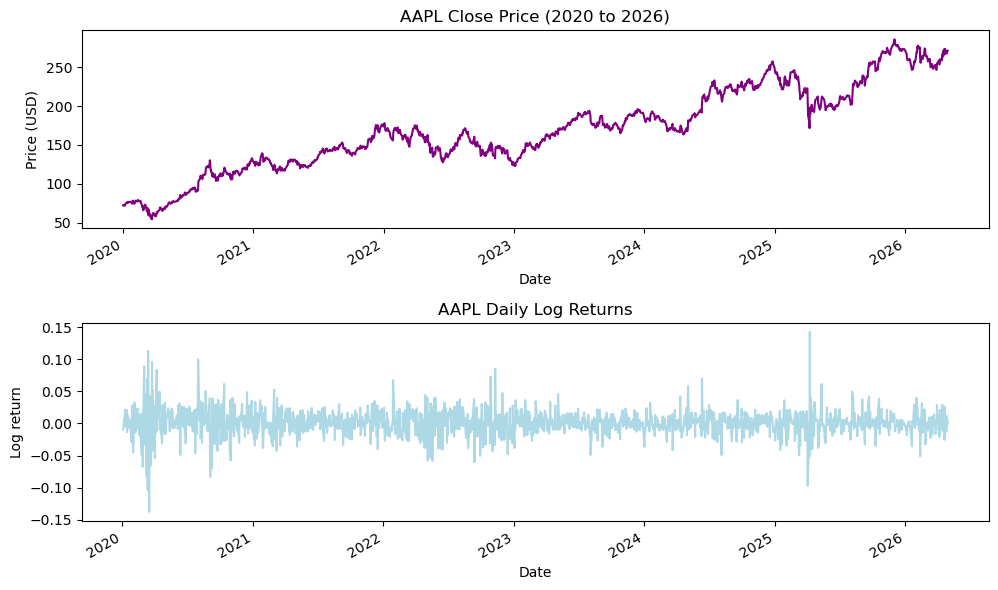

  SECTION 2 : BINOMIAL TREE PRICE
  Risk-neutral q        : 0.491202
  No-arbitrage check    : 0.9567 < e^(r*dt) = 1.0002 < 1.0452
  Binomial price at t=0 : 14.0418 USD

  SECTION 3 : ROBUSTNESS CHECK (5x5 grid over sigma and r)
  Price surface:
r           0.00%      0.50%      1.00%      1.50%      2.00%
sigma                                                        
0.2503  10.984060  11.144859  11.306996  11.470467  11.635267
0.2815  12.354480  12.514060  12.674800  12.836697  12.999748
0.3128  13.723995  13.882374  14.041773  14.202187  14.363613
0.3441  15.092510  15.249704  15.407800  15.566797  15.726691
0.3754  16.459921  16.615939  16.772764  16.930394  17.088825

  Baseline (sigma_hat, r=1%): 14.0418 USD
  P&L vs baseline:
r        0.00%   0.50%   1.00%   1.50%   2.00%
sigma                                         
0.2503 -3.0577 -2.8969 -2.7348 -2.5713 -2.4065
0.2815 -1.6873 -1.5277 -1.3670 -1.2051 -1.0420
0.3128 -0.3178 -0.1594 +0.0000 +0.1604 +0.3218
0.3441 +1.0507 +1.2079 

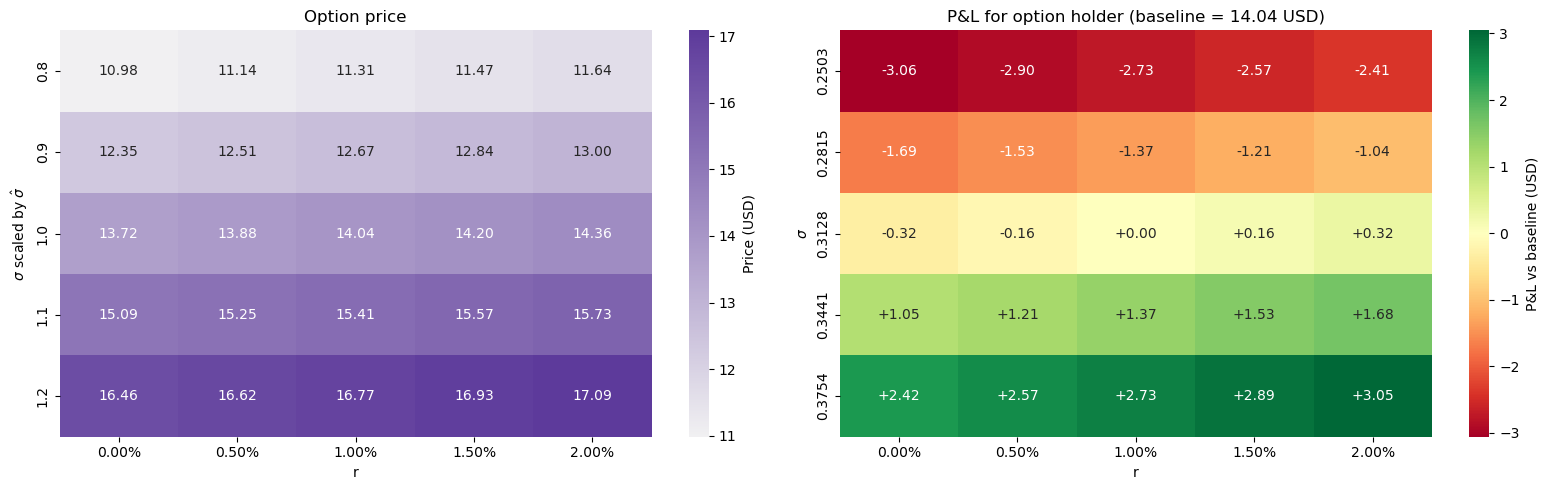

  SECTION 4 : MONTE CARLO SANITY CHECK (200,000 paths)
  MC price              : 13.9071 USD
  Standard error        : 0.0521
  95% CI                : [13.8050, 14.0092]
  Binomial price (ref)  : 14.0418 USD
  |MC  vs  binomial|    : 0.1346 USD
  Binomial inside CI?   : False

  SECTION 5 : NORMAL APPROXIMATION
  m_1                   : 1.000200   (e^(r*dt) = 1.000200)
  m_2                   : 1.002358
  E[S_n]                : 272.0669 USD
  mu_D                  : 0.6790 USD
  sigma_D               : 35.0456 USD
  z = mu_D / sigma_D    : 0.0194
  Normal-approx price   : 14.2519 USD
  Rel. diff vs binomial : +1.50%


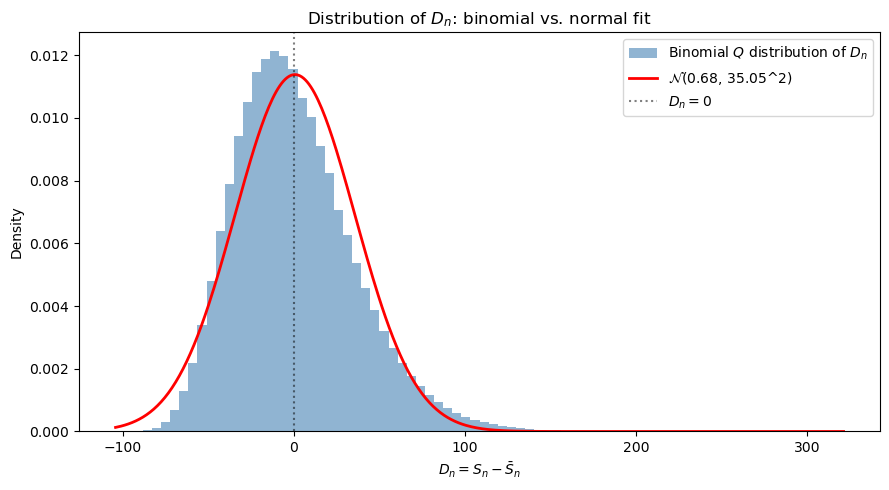


  FINAL HEADLINE NUMBERS
  S_0 (2026-04-28)            : 270.71 USD
  sigma (annualised)          : 0.3128
  T = 0.5   n = 25   r = 1.0%
  ..................................................................
  Binomial price (exact)      = 14.0418 USD
  Monte Carlo (200k paths)    = 13.9071 USD  (±0.1021)
  Normal approximation        = 14.2519 USD
  Relative diff (norm vs bin) = +1.50%


In [ ]:
# AI written code to summarize the entire paper

# ============================================================================
#  FULL PROJECT SUMMARY
#  Pricing a Floating-Strike Asian Call Option on Apple Inc.
# ============================================================================

# 1. DATA AND PARAMETER ESTIMATION ------------------------------------------
print("=" * 70)
print("  SECTION 1 : DATA AND PARAMETER ESTIMATION")
print("=" * 70)
print(f"  Date range            : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Daily prices loaded   : {len(prices)}")
print(f"  Missing values        : {int(prices.isna().sum())}")
print(f"  S_0 (2026-04-28)      : {S0:.2f} USD")
print(f"  sigma_daily           : {sigma_daily:.6f}")
print(f"  sigma (annualised)    : {sigma:.4f}")
print(f"  T = {T}   n = {n}   dt = {dt:.6f}   r = {r:.2%}   p = {p}")
print(f"  u                     : {u:.6f}")
print(f"  d                     : {d:.6f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020 to 2026)", color="purple")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="lightblue")
axes[1].set_ylabel("Log return")
plt.tight_layout(); plt.show()

# 2. BINOMIAL TREE ----------------------------------------------------------
print("=" * 70)
print("  SECTION 2 : BINOMIAL TREE PRICE")
print("=" * 70)
print(f"  Risk-neutral q        : {q:.6f}")
print(f"  No-arbitrage check    : {d:.4f} < e^(r*dt) = {np.exp(r*dt):.4f} < {u:.4f}")
print(f"  Binomial price at t=0 : {price_binomial:.4f} USD")

# 3. ROBUSTNESS CHECK -------------------------------------------------------
print()
print("=" * 70)
print("  SECTION 3 : ROBUSTNESS CHECK (5x5 grid over sigma and r)")
print("=" * 70)
print("  Price surface:")
print(results.to_string())
print()
print(f"  Baseline (sigma_hat, r=1%): {baseline:.4f} USD")
print("  P&L vs baseline:")
print(pnl.to_string(float_format=lambda x: f"{x:+.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
purple_cmap = sns.light_palette("#5d3a9b", as_cmap=True)
results_labeled = results.copy()
results_labeled.index = [f"{m:.1f}" for m in [0.8, 0.9, 1.0, 1.1, 1.2]]
axes[0].grid(False)
sns.heatmap(results_labeled, annot=True, fmt=".2f", cmap=purple_cmap,
            cbar_kws={"label": "Price (USD)"}, ax=axes[0])
axes[0].set_title("Option price")
axes[0].set_xlabel("r"); axes[0].set_ylabel(r"$\sigma$ scaled by $\hat{\sigma}$")
axes[1].grid(False)
sns.heatmap(pnl, annot=True, fmt="+.2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "P&L vs baseline (USD)"}, ax=axes[1])
axes[1].set_title(f"P&L for option holder (baseline = {baseline:.2f} USD)")
axes[1].set_xlabel("r"); axes[1].set_ylabel(r"$\sigma$")
plt.tight_layout(); plt.show()

# 4. MONTE CARLO ------------------------------------------------------------
print("=" * 70)
print("  SECTION 4 : MONTE CARLO SANITY CHECK (200,000 paths)")
print("=" * 70)
ci_lo_s = mc_price - 1.96 * mc_se
ci_hi_s = mc_price + 1.96 * mc_se
print(f"  MC price              : {mc_price:.4f} USD")
print(f"  Standard error        : {mc_se:.4f}")
print(f"  95% CI                : [{ci_lo_s:.4f}, {ci_hi_s:.4f}]")
print(f"  Binomial price (ref)  : {price_binomial:.4f} USD")
print(f"  |MC  vs  binomial|    : {abs(mc_price - price_binomial):.4f} USD")
print(f"  Binomial inside CI?   : {ci_lo_s <= price_binomial <= ci_hi_s}")

# 5. NORMAL APPROXIMATION ---------------------------------------------------
print()
print("=" * 70)
print("  SECTION 5 : NORMAL APPROXIMATION")
print("=" * 70)
print(f"  m_1                   : {m1:.6f}   (e^(r*dt) = {np.exp(r*dt):.6f})")
print(f"  m_2                   : {m2:.6f}")
print(f"  E[S_n]                : {ES[n]:.4f} USD")
print(f"  mu_D                  : {mu_D:.4f} USD")
print(f"  sigma_D               : {sigma_D:.4f} USD")
print(f"  z = mu_D / sigma_D    : {z:.4f}")
print(f"  Normal-approx price   : {price_normal:.4f} USD")
print(f"  Rel. diff vs binomial : {(price_normal - price_binomial) / price_binomial:+.2%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(Dn_values, bins=80, weights=Dn_probs, density=True,
        alpha=0.6, color="steelblue", label=r"Binomial $Q$ distribution of $D_n$")
xx = np.linspace(Dn_values.min(), Dn_values.max(), 400)
ax.plot(xx, norm.pdf(xx, loc=mu_D, scale=sigma_D), "r-", lw=2,
        label=r"$\mathcal{N}$" + f"({mu_D:.2f}, {sigma_D:.2f}^2)")
ax.axvline(0, color="k", linestyle=":", alpha=0.5, label=r"$D_n = 0$")
ax.set_xlabel(r"$D_n = S_n - \bar{S}_n$"); ax.set_ylabel("Density")
ax.set_title(r"Distribution of $D_n$: binomial vs. normal fit")
ax.legend(); plt.tight_layout(); plt.show()

# FINAL HEADLINE ------------------------------------------------------------
print()
print("=" * 70)
print("  FINAL HEADLINE NUMBERS")
print("=" * 70)
print(f"  S_0 (2026-04-28)            : {S0:.2f} USD")
print(f"  sigma (annualised)          : {sigma:.4f}")
print(f"  T = {T}   n = {n}   r = {r:.1%}")
print("  " + "." * 66)
print(f"  Binomial price (exact)      = {price_binomial:.4f} USD")
print(f"  Monte Carlo (200k paths)    = {mc_price:.4f} USD  (±{1.96 * mc_se:.4f})")
print(f"  Normal approximation        = {price_normal:.4f} USD")
print(f"  Relative diff (norm vs bin) = {(price_normal - price_binomial) / price_binomial:+.2%}")
print("=" * 70)

<a id="appendix"></a>
## Appendix A. Derivations



### A.1. u and d

*CH 3, slides 7 & 27.*

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t
$$

$$
d(\log S_t) = \left(\mu - \tfrac{1}{2}\sigma^{2}\right)dt + \sigma\,dW_t
$$

$$
\log S_{t+\Delta t} - \log S_t = \left(\mu - \tfrac{1}{2}\sigma^{2}\right)\Delta t + \sigma\bigl(W_{t+\Delta t} - W_t\bigr)
$$

$$
\operatorname{Var}\!\bigl[\log S_{t+\Delta t} - \log S_t\bigr] = \sigma^{2}\,\Delta t \qquad\qquad (\star)
$$

$$
\log\!\frac{S_{t+\Delta t}}{S_t} =
\begin{cases}
\log u & \text{with prob. } \tfrac{1}{2}, \\
\log d & \text{with prob. } \tfrac{1}{2}.
\end{cases}
$$

$$
\operatorname{Var}\!\left[\log\frac{S_{t+\Delta t}}{S_t}\right] = \tfrac{1}{4}(\log u - \log d)^{2}
$$

$$
u \cdot d = 1 \;\Longleftrightarrow\; \log d = -\log u
$$

$$
\operatorname{Var}\!\left[\log\frac{S_{t+\Delta t}}{S_t}\right] = (\log u)^{2}
$$

$$
(\log u)^{2} = \sigma^{2}\,\Delta t
$$

$$
\log u = \sigma\sqrt{\Delta t}
$$

$$
\boxed{\;u = e^{\sigma\sqrt{\Delta t}}, \qquad d = e^{-\sigma\sqrt{\Delta t}} = \frac{1}{u}\;}
$$




### A.2. Derivation of the risk-neutral probability $q$

*CH 2, slides 28–32.*

*Note on discounting: the slides use the simple-compounding factor $1/(1+r)$ over a unit step; we use the continuous-compounding factor $\mathrm{disc} = e^{-r\Delta t}$ over a step of length $\Delta t$. The two conventions coincide in the limit and yield the same $q$ once $r$ is interpreted accordingly.*

$$
S_{t+\Delta t} = \begin{cases} S_t u & \text{with prob. } p, \\ S_t d & \text{with prob. } 1-p, \end{cases}
\qquad
B_{t+\Delta t} = B_t\,e^{r\Delta t}
$$

$$
\alpha S_t u + \beta\,e^{r\Delta t} = X^u \qquad\qquad (1)
$$

$$
\alpha S_t d + \beta\,e^{r\Delta t} = X^d \qquad\qquad (2)
$$

$$
\alpha S_t (u - d) = X^u - X^d
$$

$$
\alpha = \frac{X^u - X^d}{(u - d)\,S_t}
$$

$$
\beta = \frac{1}{e^{r\Delta t}}\cdot\frac{u\,X^d - d\,X^u}{u - d}
$$

$$
V_t = \alpha S_t + \beta = \frac{X^u - X^d}{u - d} + \frac{1}{e^{r\Delta t}}\cdot\frac{u\,X^d - d\,X^u}{u - d}
$$

$$
V_t = \frac{1}{e^{r\Delta t}}\!\left[\frac{e^{r\Delta t} - d}{u - d}\,X^u + \frac{u - e^{r\Delta t}}{u - d}\,X^d\right]
$$

$$
q := \frac{e^{r\Delta t} - d}{u - d}, \qquad 1 - q = \frac{u - e^{r\Delta t}}{u - d}
$$

$$
V_t = e^{-r\Delta t}\bigl[\,q\,X^u + (1 - q)\,X^d\,\bigr] = e^{-r\Delta t}\,\mathbb{E}^{Q}[X_{t+\Delta t}\mid\mathcal{F}_t]
$$

#### Equivalent martingale derivation

$$
S_t = e^{-r\Delta t}\bigl[\,q\,S_t u + (1-q)\,S_t d\,\bigr]
$$

$$
e^{r\Delta t} = q\,u + (1-q)\,d
$$

$$
\boxed{\;q = \frac{e^{r\Delta t} - d}{u - d}\;}
$$

#### No-arbitrage domain (CH 2, slide 24)

$$
0 < q < 1 \;\Longleftrightarrow\; d < e^{r\Delta t} < u
$$




### A.3. Derivation of the forward $(t,j,C)$ update (Equation 6)

*CH 2, slides 22 & 38.*

At node $(t, j, C)$ we have $S_{t,j} = S_0\,u^{j} d^{\,t-j}$ (CH 2, slide 38) and $C_t = \sum_{k=0}^{t} S_k$ (definition).

The per-step law is $S_{t+1} = S_t\,\xi_{t+1}$ with $\xi \in \{u, d\}$ (CH 2, slide 22), so

$$
S_{t,j}\,u = S_0\,u^{j+1} d^{\,(t+1)-(j+1)} = S_{t+1,\,j+1} \qquad (\text{up-count}\to j+1),
$$

$$
S_{t,j}\,d = S_0\,u^{j}\,d^{\,(t+1)-j} = S_{t+1,\,j} \qquad (\text{up-count unchanged}).
$$

The cumulative sum updates as $C_{t+1} = C_t + S_{t+1}$, giving $C + S_{t,j}\,u$ on the up branch and $C + S_{t,j}\,d$ on the down branch. Hence

$$
\boxed{\;(t, j, C) \;\longrightarrow\; \begin{cases} (t+1,\, j+1,\, C + S_{t,j}\,u) & \text{(up)}, \\[2pt] (t+1,\, j,\;\;\, C + S_{t,j}\,d) & \text{(down)}. \end{cases}\;}
$$




### A.4. Derivation of the backward induction (Equation 7)

Let $X^{u} := V_{t+1}(j+1,\, C + S_{t,j}\,u)$ and $X^{d} := V_{t+1}(j,\, C + S_{t,j}\,d)$. A one-period replicating portfolio $H = (\alpha, \beta)$ satisfies the system (CH 2, slides 28–29)

$$
\alpha\,S_{t,j}\,u + \beta\,e^{r\Delta t} = X^{u} \qquad\qquad (\text{i})
$$

$$
\alpha\,S_{t,j}\,d + \beta\,e^{r\Delta t} = X^{d} \qquad\qquad (\text{ii})
$$

Subtracting (ii) from (i) and solving for $\alpha$ (CH 2, slide 31):

$$
\alpha\,S_{t,j}(u - d) = X^{u} - X^{d} \;\Longrightarrow\; \alpha = \frac{X^{u} - X^{d}}{(u - d)\,S_{t,j}}.
$$

Substituting back into (i) and solving for $\beta$ (CH 2, slide 31):

$$
\beta\,e^{r\Delta t} = \frac{u\,X^{d} - d\,X^{u}}{u - d} \;\Longrightarrow\; \beta = e^{-r\Delta t}\cdot\frac{u\,X^{d} - d\,X^{u}}{u - d}.
$$

The price equals the cost of the portfolio (CH 2, slide 32):

$$
V_t(j, C) = \alpha\,S_{t,j} + \beta = \frac{X^{u} - X^{d}}{u - d} + e^{-r\Delta t}\cdot\frac{u\,X^{d} - d\,X^{u}}{u - d} = e^{-r\Delta t}\bigl[\,q\,X^{u} + (1 - q)\,X^{d}\,\bigr],
$$

with $q = \dfrac{e^{r\Delta t} - d}{u - d}$ and $1 - q = \dfrac{u - e^{r\Delta t}}{u - d}$ as in A.2 (CH 2, slide 32).

Reinserting $X^{u}, X^{d}$ via the $C$-update rule from A.3:

$$
\boxed{\;V_t(j, C) = e^{-r\Delta t}\bigl[\,q\,V_{t+1}(j+1,\, C + S_{t,j}\,u) + (1 - q)\,V_{t+1}(j,\, C + S_{t,j}\,d)\,\bigr]\;}
$$

The terminal triple $V_n(j, C) = \max\!\bigl(S_{n,j} - C/(n+1),\, 0\bigr)$ seeds the recursion; iterating from $t = n-1$ down to $t = 0$ collapses to $V_0(0, S_0)$ by the Multiple-Period Case Theorem (CH 2, slide 39).

### A.5 &nbsp; Per-step return moments under $\mathbb{Q}$

Under the risk-neutral measure $\mathbb{Q}$ (Chapter 2, slides 28&ndash;34), each one-step gross return $R_t := S_{t+1}/S_t$ takes the value $u$ with probability $q$ and $d$ with probability $1-q$. We define the first two raw moments of $R_t$ under $\mathbb{Q}$ as

$$
m_1 \;:=\; \mathbb{E}^{\mathbb{Q}}[R_t] \;=\; q u + (1-q) d, \qquad m_2 \;:=\; \mathbb{E}^{\mathbb{Q}}[R_t^2] \;=\; q u^2 + (1-q) d^2.
$$

The first moment satisfies $m_1 = e^{r \Delta t}$. To see this, substitute $q = (e^{r \Delta t} - d)/(u - d)$ from Appendix A.2:

$$
m_1 \;=\; \frac{(e^{r \Delta t} - d)\, u + (u - e^{r \Delta t})\, d}{u - d} \;=\; \frac{u\, e^{r \Delta t} - u d + u d - d\, e^{r \Delta t}}{u - d} \;=\; \frac{(u - d)\, e^{r \Delta t}}{u - d} \;=\; e^{r \Delta t}.
$$

This is the *martingale property* of the discounted stock price: $\mathbb{E}^{\mathbb{Q}}[S_{t+1} \mid S_t] = e^{r \Delta t} S_t$, so $e^{-r(t+1) \Delta t} \mathbb{E}^{\mathbb{Q}}[S_{t+1}] = e^{-r t \Delta t} S_t$.

The second moment $m_2$ does not have a comparably clean closed form in terms of the underlying parameters; we leave it as defined above and use the explicit expression in numerical computations.

### A.6 &nbsp; Mean of $S_t$ under $\mathbb{Q}$

Iterating the multiplicative dynamics from $t=0$:

$$
S_t \;=\; S_0 \cdot R_1 \cdot R_2 \cdots R_t.
$$

Under $\mathbb{Q}$ the returns $R_1, \ldots, R_t$ are i.i.d. (Chapter 2, slide 38), so the expectation of the product factors:

$$
\mathbb{E}^{\mathbb{Q}}[S_t] \;=\; \mathbb{E}^{\mathbb{Q}}[S_0 \cdot R_1 \cdots R_t] \;=\; S_0 \cdot \mathbb{E}^{\mathbb{Q}}[R_1] \cdots \mathbb{E}^{\mathbb{Q}}[R_t] \;=\; S_0 \cdot m_1^{\,t}.
$$

Equivalently, $\mathbb{E}^{\mathbb{Q}}[S_t] = S_0 \cdot e^{r t \Delta t}$, confirming the martingale property of the discounted price process.

### A.7 &nbsp; The master moment formula

Take any two time-steps with $s \leq t$. Write

$$
S_t \;=\; S_s \cdot \frac{S_t}{S_s}, \qquad \text{so that} \qquad S_s \cdot S_t \;=\; S_s^2 \cdot \frac{S_t}{S_s}.
$$

The factor $S_s^2$ is determined by returns over $[0, s]$, while $S_t/S_s = R_{s+1} R_{s+2} \cdots R_t$ is determined by returns over $[s, t]$. These windows are disjoint, so under the i.i.d. assumption the two factors are independent:

$$
\mathbb{E}^{\mathbb{Q}}[S_s \cdot S_t] \;=\; \mathbb{E}^{\mathbb{Q}}[S_s^2] \cdot \mathbb{E}^{\mathbb{Q}}\!\left[\frac{S_t}{S_s}\right].
$$

Each factor reduces by the same iteration as in A.6:

- **$\mathbb{E}^{\mathbb{Q}}[S_s^2] = S_0^2 \cdot m_2^{\,s}$.** Indeed, $S_s^2 = S_0^2 \cdot R_1^2 R_2^2 \cdots R_s^2$, and the squared returns $R_i^2$ are mutually independent (functions of independent variables); each has expectation $\mathbb{E}^{\mathbb{Q}}[R_i^2] = m_2$.
- **$\mathbb{E}^{\mathbb{Q}}[S_t/S_s] = m_1^{\,t-s}$.** The ratio is a product of $t-s$ independent returns, each with mean $m_1$.

Multiplying:

$$
\mathbb{E}^{\mathbb{Q}}[S_s \cdot S_t] \;=\; S_0^2 \cdot m_2^{\,s} \cdot m_1^{\,t-s} \qquad (s \leq t).
$$

For arbitrary, unordered $s, t$ the symmetric form is

$$
\boxed{\;\mathbb{E}^{\mathbb{Q}}[S_s \cdot S_t] \;=\; S_0^2 \cdot m_2^{\min(s,t)} \cdot m_1^{|t-s|}\;}
$$

which we will call the *master moment formula*. The covariance follows immediately:

$$
\mathrm{Cov}^{\mathbb{Q}}(S_s, S_t) \;=\; \mathbb{E}^{\mathbb{Q}}[S_s S_t] - \mathbb{E}^{\mathbb{Q}}[S_s]\,\mathbb{E}^{\mathbb{Q}}[S_t] \;=\; S_0^2 \bigl(m_2^{\min(s,t)} m_1^{|t-s|} - m_1^{s+t}\bigr).
$$

Specializing to $s = t$ recovers the variance: $\mathrm{Var}^{\mathbb{Q}}(S_t) = S_0^2 (m_2^t - m_1^{2t})$, which is non-negative because $m_2 \geq m_1^2$ by the Cauchy&ndash;Schwarz inequality.

### A.8 &nbsp; $D_n$ as a linear combination of the path

Starting from the definition $D_n = S_n - \frac{1}{n+1}\sum_{t=0}^n S_t$ and distributing the $\frac{1}{n+1}$ across all terms of the sum, then collecting the contributions of each $S_t$:

$$
D_n \;=\; S_n - \frac{S_0}{n+1} - \frac{S_1}{n+1} - \cdots - \frac{S_{n-1}}{n+1} - \frac{S_n}{n+1}.
$$

The terminal price $S_n$ appears twice: once with coefficient $+1$ and once with coefficient $-\frac{1}{n+1}$. Combining and grouping:

$$
\boxed{\;D_n \;=\; \sum_{t=0}^n a_t \, S_t \;}
$$

with coefficients

$$
a_n \;=\; 1 - \frac{1}{n+1}, \qquad a_t \;=\; -\frac{1}{n+1} \quad \text{for } t \in \{0, 1, \ldots, n-1\}.
$$

A useful identity: the coefficients sum to zero,

$$
\sum_{t=0}^{n} a_t \;=\; \left(1 - \frac{1}{n+1}\right) + n \cdot \left(-\frac{1}{n+1}\right) \;=\; 1 - \frac{n+1}{n+1} \;=\; 0.
$$

Geometrically, $D_n$ is a *zero-sum* linear combination of the path: the positive weight on the terminal price exactly balances the negative weights on the earlier prices.

### A.9 &nbsp; Mean of $D_n$ via linearity of expectation

Linearity of expectation (Chapter 1) holds for any random variables, independent or not. Applying it to the linear combination from A.8:

$$
\mu_D \;:=\; \mathbb{E}^{\mathbb{Q}}[D_n] \;=\; \mathbb{E}^{\mathbb{Q}}\!\left[\sum_{t=0}^n a_t S_t\right] \;=\; \sum_{t=0}^n a_t \,\mathbb{E}^{\mathbb{Q}}[S_t] \;=\; \sum_{t=0}^n a_t \, S_0 \, m_1^{\,t},
$$

using A.6 in the final equality. In matrix form, $\mu_D = a^\top \mathbb{E}[S]$ where $a = (a_0, \ldots, a_n)^\top$ and $\mathbb{E}[S] = (S_0, S_0 m_1, \ldots, S_0 m_1^n)^\top$. The inner sum on the right-hand side is a finite geometric series, and could be evaluated symbolically as

$$
\mu_D \;=\; S_0 \left[\, m_1^n - \frac{1}{n+1} \cdot \frac{m_1^{n+1} - 1}{m_1 - 1} \,\right],
$$

though we use the matrix form computationally for clarity and reusability.

For typical parameter regimes ($r > 0$, hence $m_1 > 1$), $\mu_D > 0$: the terminal price exceeds the average of earlier prices in expectation, because of positive drift.

### A.10 &nbsp; Variance of $D_n$

Variance is *not* linear; for a linear combination of correlated random variables the variance involves all pairwise covariances. Specifically, Chapter 5 (slide 6) establishes that for a weight vector $x \in \mathbb{R}^{n+1}$ and a covariance matrix $V \in \mathbb{R}^{(n+1) \times (n+1)}$ of underlying variables,

$$
\mathrm{Var}\!\left(\sum_t x_t Y_t\right) \;=\; x^\top V x \;=\; \sum_{s, t} x_s x_t \mathrm{Cov}(Y_s, Y_t).
$$

In the lecture's portfolio context the $Y_t$ are asset returns and the $x_t$ are portfolio weights. The formula is general, however: it applies to any linear combination of correlated random variables, regardless of the source of the correlation. Applying it to $D_n = \sum_t a_t S_t$ with $V_{st} = \mathrm{Cov}^{\mathbb{Q}}(S_s, S_t)$:

$$
\boxed{\;\sigma_D^2 \;:=\; \mathrm{Var}^{\mathbb{Q}}(D_n) \;=\; a^\top V a \;=\; \sum_{s=0}^n \sum_{t=0}^n a_s a_t \,\mathrm{Cov}^{\mathbb{Q}}(S_s, S_t).\;}
$$

Each entry $V_{st}$ is computed in closed form using the master moment formula A.7:

$$
V_{st} \;=\; S_0^2 \bigl(m_2^{\min(s,t)} m_1^{|t-s|} - m_1^{s+t}\bigr).
$$

Equivalently, expanding the matrix product using $D_n = S_n - \bar{S}_n$:

$$
\mathrm{Var}^{\mathbb{Q}}(D_n) \;=\; \mathrm{Var}^{\mathbb{Q}}(S_n) \;-\; \frac{2}{n+1}\sum_{t=0}^n \mathrm{Cov}^{\mathbb{Q}}(S_n, S_t) \;+\; \frac{1}{(n+1)^2}\sum_{s=0}^n \sum_{t=0}^n \mathrm{Cov}^{\mathbb{Q}}(S_s, S_t),
$$

which is the same number written in three explicit pieces, a useful form for sanity-checking the matrix computation against a more elementary expansion. Since $V$ is positive semi-definite (a general property of any covariance matrix; Chapter 1, slide 55), the quadratic form $a^\top V a$ is non-negative, so $\sigma_D^2 \geq 0$ as it must be.

### A.11 &nbsp; The Bachelier identity

We need the expected positive part of a normal random variable. For $X \sim \mathcal{N}(\mu, \sigma^2)$ with $\sigma > 0$:

$$
\mathbb{E}[\max(X, 0)] \;=\; \int_{0}^{\infty} x \cdot \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}\, dx.
$$

**Step 1: standardize.** Substitute $z = (x - \mu)/\sigma$, so $x = \mu + \sigma z$ and $dx = \sigma\, dz$. The lower limit $x = 0$ becomes $z = -\mu/\sigma$, the upper limit $x \to \infty$ stays $z \to \infty$:

$$
\mathbb{E}[\max(X, 0)] \;=\; \int_{-\mu/\sigma}^{\infty} (\mu + \sigma z)\, \varphi(z)\, dz,
$$

where $\varphi(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$ is the standard normal density.

**Step 2: split the integrand.** Linearity of integration gives

$$
\mathbb{E}[\max(X, 0)] \;=\; \mu \int_{-\mu/\sigma}^{\infty} \varphi(z)\, dz \;+\; \sigma \int_{-\mu/\sigma}^{\infty} z\, \varphi(z)\, dz.
$$

**Step 3: evaluate each piece.**

*First integral*, the area under $\varphi$ to the right of $-\mu/\sigma$:

$$
\int_{-\mu/\sigma}^{\infty} \varphi(z)\, dz \;=\; 1 - \Phi(-\mu/\sigma) \;=\; \Phi(\mu/\sigma),
$$

using the symmetry $\Phi(-z) = 1 - \Phi(z)$ of the standard normal CDF.

*Second integral*, observe that the antiderivative of $z\, \varphi(z)$ is $-\varphi(z)$:

$$
\frac{d}{dz}\!\bigl[-\varphi(z)\bigr] \;=\; \frac{d}{dz}\!\left[-\frac{1}{\sqrt{2\pi}}e^{-z^2/2}\right] \;=\; z\, \varphi(z).
$$

Hence

$$
\int_{-\mu/\sigma}^{\infty} z\, \varphi(z)\, dz \;=\; \bigl[-\varphi(z)\bigr]_{-\mu/\sigma}^{\infty} \;=\; 0 - (-\varphi(-\mu/\sigma)) \;=\; \varphi(\mu/\sigma),
$$

using the symmetry $\varphi(-z) = \varphi(z)$.

**Step 4: assemble.**

$$
\boxed{\;\mathbb{E}[\max(X, 0)] \;=\; \mu \,\Phi(\mu/\sigma) \;+\; \sigma\, \varphi(\mu/\sigma)\;}
$$

valid for any $X \sim \mathcal{N}(\mu, \sigma^2)$. This is the *Bachelier identity*, the central analytical result underlying the normal-approximation pricer.

In the limit $\mu/\sigma \to \infty$ (option deeply in the money), $\Phi(\mu/\sigma) \to 1$ and $\varphi(\mu/\sigma) \to 0$, so $\mathbb{E}[\max(X, 0)] \to \mu$. In the limit $\mu/\sigma \to -\infty$ (option deeply out of the money), both terms vanish, so $\mathbb{E}[\max(X, 0)] \to 0$. Both are the expected behaviour.

### A.12 &nbsp; Closed-form normal-approximation price

Combining the FTAP (Appendix A.4), the normal approximation $D_n \approx \mathcal{N}(\mu_D, \sigma_D^2)$, and the Bachelier identity (A.11):

$$
V_0^{\text{normal}} \;=\; e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\max(D_n, 0)] \;\approx\; e^{-rT}\!\left[\,\mu_D \,\Phi\!\left(\tfrac{\mu_D}{\sigma_D}\right) \;+\; \sigma_D\, \varphi\!\left(\tfrac{\mu_D}{\sigma_D}\right)\,\right]
$$

with $\mu_D$ and $\sigma_D^2$ given by A.9 and A.10 respectively. This is the closed-form pricer implemented in Section 5.